# Differential-expression count summary

Remote source reviewed from `20260103-p38/DEG.ipynb`. Run from top to bottom after configuring `config/paths.*`.


In [ ]:
# Centralized paths and scheduler-aware thread limits.
repo_root <- if (file.exists("config/paths.R")) "." else if (file.exists("../config/paths.R")) ".." else stop("Run Jupyter from the repository root or notebooks/ directory.")
source(file.path(repo_root, "config", "paths.R"))


In [1]:
library(Seurat)
library(ggplot2)
library(dplyr)
library(tidyr)

# --- 1. 加载数据 ---
# 注意：这里将变量名统一为 sce，方便后续调用
sce <- readRDS(legacy_path("20250604p38-afterYZ/anno.rds"))

Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built under R 4.4.1 but the current version is
4.4.2; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "正在计算差异基因数 (KO vs WT)..."


Cluster 0 计算完成

Cluster 1 计算完成

Cluster 2 计算完成

Cluster 3 计算完成

Cluster 4 计算完成

Cluster 5 计算完成

Cluster 6 计算完成

Cluster 7 计算完成

Cluster 8 计算完成

Cluster 9 计算完成

Cluster 10 计算完成

Cluster 11 计算完成

Cluster 12 计算完成

Cluster 13 计算完成

Cluster 14 计算完成



[1] "各亚群差异基因 (DEG) 统计清单："
   Cluster  Up Down Total
5        5 797  346  1143
3        3 430  323   753
4        4 585  167   752
2        2 455  189   644
10      10 314  181   495
1        1 158  282   440
0        0 272  109   381
9        9 225  119   344
8        8 227  109   336
11      11 196  123   319
6        6 210   90   300
7        7 164   71   235
13      13  39   23    62
12      12  23   22    45
14      14   8   14    22


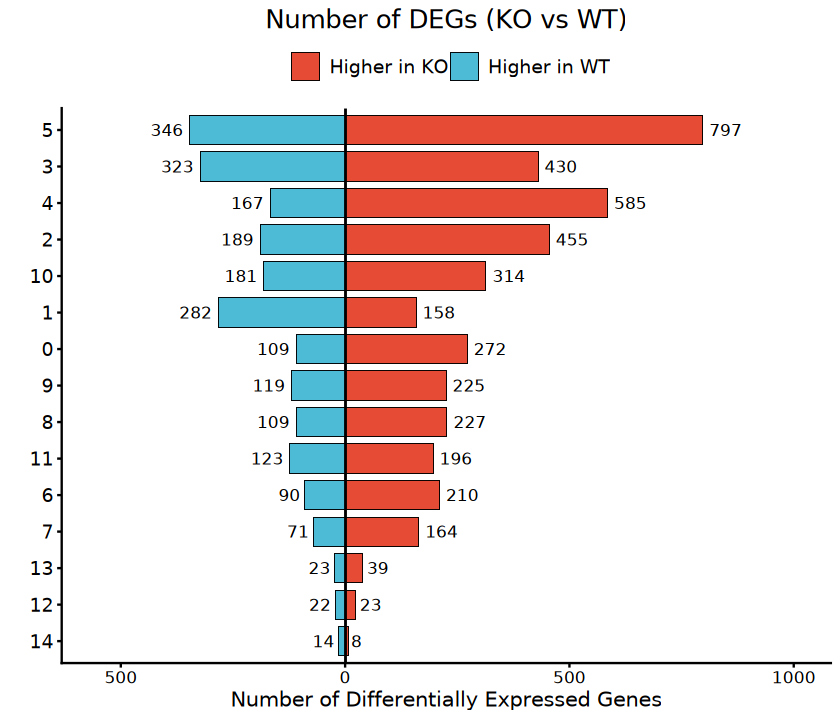

In [2]:
# 检查分组名称是否存在于 orig.ident 中
if (!all(c("KO", "WT") %in% unique(sce$orig.ident))) {
  stop("错误：在 orig.ident 中未找到 KO 或 WT，请检查数据！")
}

# --- 2. 批量计算所有 Cluster 的差异基因数 ---
clusters <- levels(sce)
deg_list <- list()

print("正在计算差异基因数 (KO vs WT)...")

for (i in clusters) {
  # 提取该亚群细胞
  cells_in_cluster <- WhichCells(sce, idents = i)
  # 统计该亚群中 KO 和 WT 的细胞数量
  cond_counts <- table(sce$orig.ident[cells_in_cluster])
  
  # 只有当 KO 和 WT 组都有且细胞数 > 10 时才进行计算
  if (all(c("KO", "WT") %in% names(cond_counts)) && all(cond_counts > 10)) {
    
    # 差异分析：ident.1="KO" (实验组), ident.2="WT" (对照组)
    markers <- FindMarkers(sce, 
                           ident.1 = "KO", 
                           ident.2 = "WT", 
                           subset.ident = i,
                           group.by = "orig.ident",
                           logfc.threshold = 0.25, 
                           min.pct = 0.1, 
                           verbose = FALSE)
    
    # 筛选显著基因 (校正后P值 < 0.05)
    sig_res <- markers %>% filter(p_val_adj < 0.05)
    
    # 统计数量
    up_count <- sum(sig_res$avg_log2FC > 0)    # KO 高表达 (Up)
    down_count <- sum(sig_res$avg_log2FC < 0)  # WT 高表达 (Down)
    
    deg_list[[i]] <- data.frame(Cluster = i, 
                                Up = up_count, 
                                Down = down_count)
    message(paste0("Cluster ", i, " 计算完成"))
  } else {
    message(paste0("Cluster ", i, " 细胞数不足，跳过"))
  }
}

# 合并数据
deg_df <- do.call(rbind, deg_list)

# --- 3. 整合绘图准备 ---
plot_deg_df <- deg_df %>%
  mutate(
    # 为了做背靠背条形图，将 Down 设为负数
    Down_Neg = -Down,
    Total = Up + Down
  ) %>%
  # 按总差异基因数从小到大排序（绘图时会因 coord_flip 变成从大到小）
  arrange(Total) 

# 锁定因子顺序，保证绘图顺序一致
plot_deg_df$Cluster <- factor(plot_deg_df$Cluster, levels = plot_deg_df$Cluster)

# 转换为长表以便 ggplot 识别颜色
plot_deg_long <- plot_deg_df %>%
  select(Cluster, Up, Down_Neg) %>%
  pivot_longer(cols = c("Up", "Down_Neg"), names_to = "Direction", values_to = "Count") %>%
  mutate(Direction = ifelse(Direction == "Up", "Higher in KO", "Higher in WT"))

# --- 4. 绘图 (Diverging Bar Plot) ---
p_deg_final <- ggplot(plot_deg_long, aes(x = Cluster, y = Count, fill = Direction)) +
  # 画条形图
  geom_bar(stat = "identity", width = 0.8, color = "black", linewidth = 0.2) +
  
  # 标注上调基因数 (KO)
  geom_text(data = filter(plot_deg_long, Direction == "Higher in KO"),
            aes(label = Count), hjust = -0.2, size = 3.5, fontface = "bold") +
  
  # 标注下调基因数 (WT，取绝对值显示)
  geom_text(data = filter(plot_deg_long, Direction == "Higher in WT"),
            aes(label = abs(Count)), hjust = 1.2, size = 3.5, fontface = "bold") +
  
  # 颜色映射 (红色代表 KO 增加，蓝色代表 WT 增加)
  scale_fill_manual(values = c("Higher in KO" = "#E64B35FF", 
                                "Higher in WT" = "#4DBBD5FF")) +
  
  # 坐标轴反转，横向显示
  coord_flip() +
  
  # 样式美化
  theme_classic() +
  theme(
    text = element_text(family = "sans"),
    plot.title = element_text(hjust = 0.5, size = 15, face = "bold"),
    axis.text.y = element_text(size = 11, face = "bold", color = "black"),
    axis.text.x = element_text(size = 10, color = "black"),
    axis.title = element_text(size = 12, face = "bold"),
    legend.position = "top",
    legend.title = element_blank(),
    legend.text = element_text(size = 11, face = "bold")
  ) +
  
  # 修正 Y 轴标签，使负值显示为正数，并给标签预留空间
  scale_y_continuous(labels = function(x) abs(x), 
                     expand = expansion(mult = c(0.25, 0.25))) + 
  
  labs(title = "Number of DEGs (KO vs WT)",
       x = "",
       y = "Number of Differentially Expressed Genes") +
  
  # 增加中间零线
  geom_hline(yintercept = 0, color = "black", linewidth = 0.6)

# 输出图形
options(repr.plot.width=7, repr.plot.height=6)
print(p_deg_final)

# 打印具体数值表，方便存为 CSV
print("各亚群差异基因 (DEG) 统计清单：")
deg_summary <- deg_df %>% mutate(Total = Up + Down) %>% arrange(desc(Total))
print(deg_summary)

# 如果需要保存结果
# write.csv(deg_summary, "DEG_count_KO_vs_WT.csv", row.names = FALSE)
# ggsave("DEG_barplot_KO_vs_WT.pdf", p_deg_final, width = 7, height = 6)

[1] "检查更名后的统计表："
                  celltype  Up Down Total
1 14 pDC-biased progenitor   8   14    22
2               12 pre-pDC  23   22    45
3                   13 CLP  39   23    62
4             7 CD115- CDP 164   71   235
5                    6 MPP 210   90   300
6              11 pre-cDC2 196  123   319


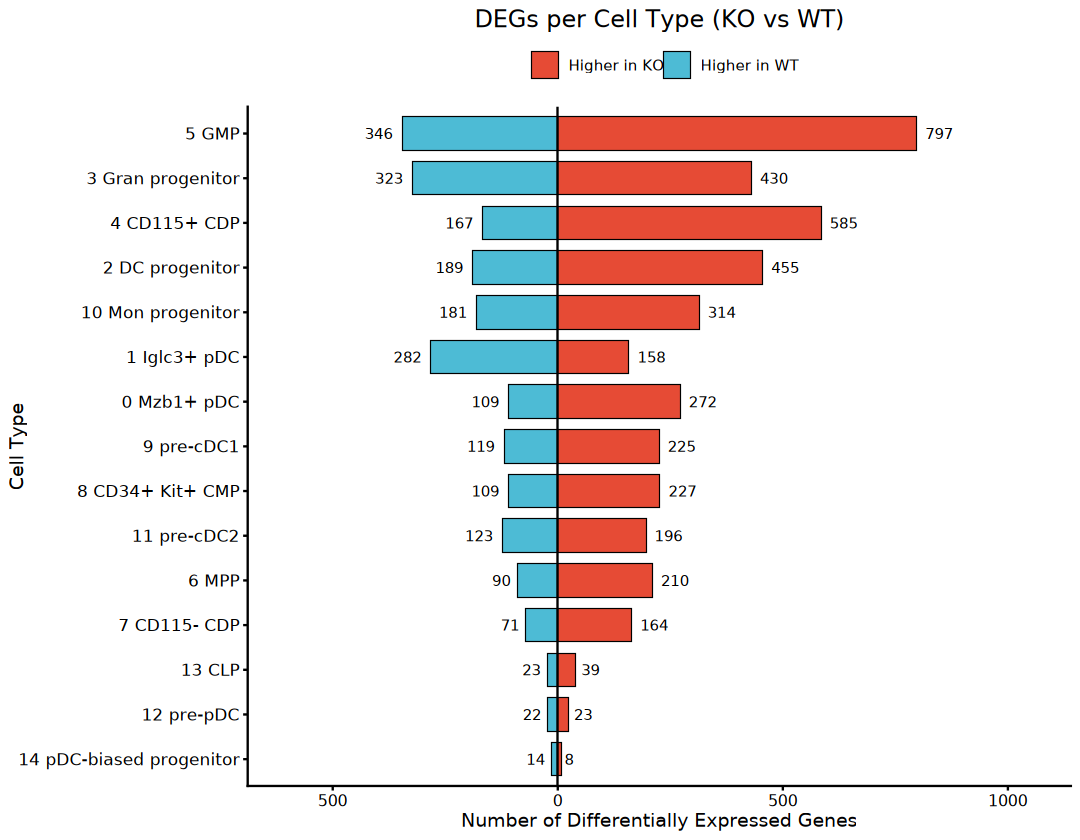

In [6]:
library(dplyr)
library(ggplot2)
library(tidyr)

# --- 1. 建立数字编号与 celltype 名称的对应关系 ---
# 从元数据中提取编号 (RNA_snn_res.0.8) 和对应的名称 (celltype)
mapping <- sce@meta.data %>%
  select(RNA_snn_res.0.8, celltype) %>%
  distinct() %>%
  mutate(RNA_snn_res.0.8 = as.character(RNA_snn_res.0.8)) # 确保是字符型以方便匹配

# --- 2. 更新 deg_df 中的名称 ---
plot_data <- deg_df %>%
  mutate(Cluster = as.character(Cluster)) %>%  # 确保 Cluster 列也是字符型
  left_join(mapping, by = c("Cluster" = "RNA_snn_res.0.8")) %>% # 把名称并进去
  mutate(
    Down_Neg = -Down,
    Total = Up + Down
  ) %>%
  # 按照总差异基因数排序
  arrange(Total)

# 锁定 celltype 为因子，确保绘图顺序从少到多（coord_flip后变多到少）
plot_data$celltype <- factor(plot_data$celltype, levels = plot_data$celltype)

# 转换为长表
plot_long <- plot_data %>%
  select(celltype, Up, Down_Neg) %>%
  pivot_longer(cols = c("Up", "Down_Neg"), names_to = "Direction", values_to = "Count") %>%
  mutate(Direction = ifelse(Direction == "Up", "Higher in KO", "Higher in WT"))

# --- 3. 绘图 (纵轴现在会显示完整的 celltype 名称) ---
p_deg_final <- ggplot(plot_long, aes(x = celltype, y = Count, fill = Direction)) +
  geom_bar(stat = "identity", width = 0.75, color = "black", linewidth = 0.25) +
  
  # 标注数字
  geom_text(data = filter(plot_long, Direction == "Higher in KO"),
            aes(label = Count), hjust = -0.3, size = 3, fontface = "bold") +
  
  geom_text(data = filter(plot_long, Direction == "Higher in WT"),
            aes(label = abs(Count)), hjust = 1.3, size = 3, fontface = "bold") +
  
  # 颜色映射
  scale_fill_manual(values = c("Higher in KO" = "#E64B35FF", 
                                "Higher in WT" = "#4DBBD5FF")) +
  
  coord_flip() +
  theme_classic() +
  theme(
    text = element_text(family = "sans"),
    plot.title = element_text(hjust = 0.5, size = 14, face = "bold"),
    axis.text.y = element_text(size = 10, face = "bold", color = "black"), # 细胞类型名称
    axis.text.x = element_text(size = 9, color = "black"),
    axis.title = element_text(size = 11, face = "bold"),
    legend.position = "top",
    legend.title = element_blank()
  ) +
  
  scale_y_continuous(labels = function(x) abs(x), 
                     expand = expansion(mult = c(0.3, 0.3))) + 
  
  labs(title = "DEGs per Cell Type (KO vs WT)",
       x = "Cell Type", 
       y = "Number of Differentially Expressed Genes") +
  
  geom_hline(yintercept = 0, color = "black", linewidth = 0.5)

# --- 4. 显示结果 ---
options(repr.plot.width=9, repr.plot.height=7)
print(p_deg_final)

# 检查一下合并后的数据表，确认名字对上了
print("检查更名后的统计表：")
print(head(plot_data %>% select(celltype, Up, Down, Total)))

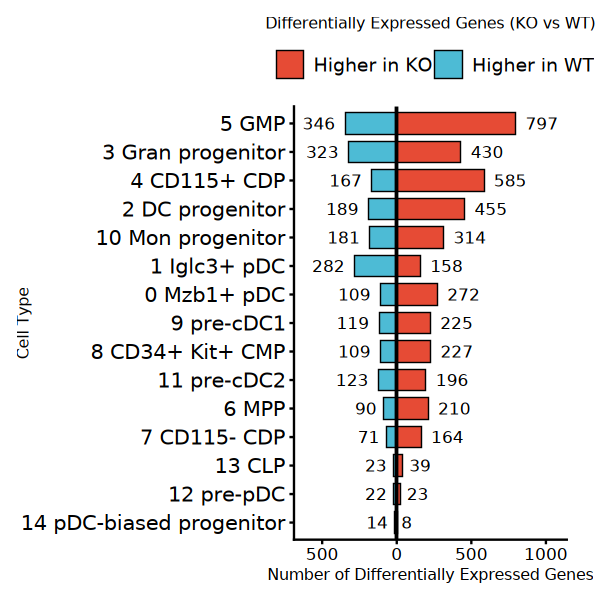

In [12]:
# --- 1. 绘图 (所有字体加粗版) ---
p_deg_final <- ggplot(plot_long, aes(x = celltype, y = Count, fill = Direction)) +
  # 条形图
  geom_bar(stat = "identity", width = 0.75, color = "black", linewidth = 0.3) +
  
  # 标注数字 (KO 侧) - 使用 fontface = "bold"
  geom_text(data = filter(plot_long, Direction == "Higher in KO"),
            aes(label = Count), 
            hjust = -0.3, 
            size = 3.5, 
            fontface = "bold") +
  
  # 标注数字 (WT 侧) - 使用 fontface = "bold"
  geom_text(data = filter(plot_long, Direction == "Higher in WT"),
            aes(label = abs(Count)), 
            hjust = 1.3, 
            size = 3.5, 
            fontface = "bold") +
  
  # 颜色映射
  scale_fill_manual(values = c("Higher in KO" = "#E64B35FF", 
                                "Higher in WT" = "#4DBBD5FF")) +
  
  # 坐标轴反转
  coord_flip() +
  
  # 样式美化
  theme_classic() +
  theme(
    # 1. 全局字体加粗 (包括标题和坐标轴)
    text = element_text(family = "sans", face = "bold"),
    
    # 2. 标题加粗
    plot.title = element_text(hjust = 0.5, size = 9, face = "bold"),
    
    # 3. 纵坐标 (celltype 名称) 加粗
    axis.text.y = element_text(size = 12, face = "bold", color = "black"),
    
    # 4. 横坐标 (数字刻度) 加粗
    axis.text.x = element_text(size = 10, face = "bold", color = "black"),
    
    # 5. 轴标题 (Cell Type / Number of DEGs) 加粗
    axis.title = element_text(size = 9, face = "bold"),
    
    # 6. 图例文字加粗
    legend.position = "top",
    legend.title = element_blank(),
    legend.text = element_text(size = 11, face = "bold"),
    
    # 调整绘图区域边距
    plot.margin = margin(t = 10, r = 20, b = 10, l = 10)
  ) +
  
  # 修正横轴显示绝对值，并增加两端空间防止加粗后的文字溢出
  scale_y_continuous(labels = function(x) abs(x), 
                     expand = expansion(mult = c(0.3, 0.3))) + 
  
  labs(title = "Differentially Expressed Genes (KO vs WT)",
       x = "Cell Type", 
       y = "Number of Differentially Expressed Genes") +
  
  # 中间分界线加粗
  geom_hline(yintercept = 0, color = "black", linewidth = 0.8)

# --- 2. 显示结果 ---
options(repr.plot.width=5, repr.plot.height=5)
print(p_deg_final)